In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
from matplotlib.transforms import blended_transform_factory

In [2]:
## -- load in retrieval results:
## 0=H2O, 1=CH4, 2=NH3, 3=HCN, 4=CO, 5=CO2,
## 6=T0, 7=alpha1, 8=alpha2, 9=logP1, 10=logP2,
## 11=logP3, 12=logPref, 13=loga, 14=gamma, 15=logPc
## 16=phi_cl/haze, 17=Rp, 18=Mp, 19=delta, 20=Thet, 21=Tphot
## 22 = log_likelihoods

## narrow (i.e. with priors) TLSE priors ('mp')
# samples:
mp_samples = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-post_equal_weights.dat')
#  median, +-1 sigma values
labels = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-1_sigma', unpack=True, usecols=[0], dtype=str)
mp_vals, mp_uperrs, mp_loerrs = np.loadtxt('./data/retrievals/star_narrow_priors/niriss_r300_lowm_star_priors-1_sigma', unpack=True, usecols=[1,2,3])

## wide (i.e. no priors) TLSE priors ('mn')
# samples:
mn_samples = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-post_equal_weights.dat')
#  median, +-1 sigma values
mn_vals, mn_uperrs, mn_loerrs = np.loadtxt('./data/retrievals/star_wide_priors/niriss_r300_lowm-1_sigma', unpack=True, usecols=[1,2,3])

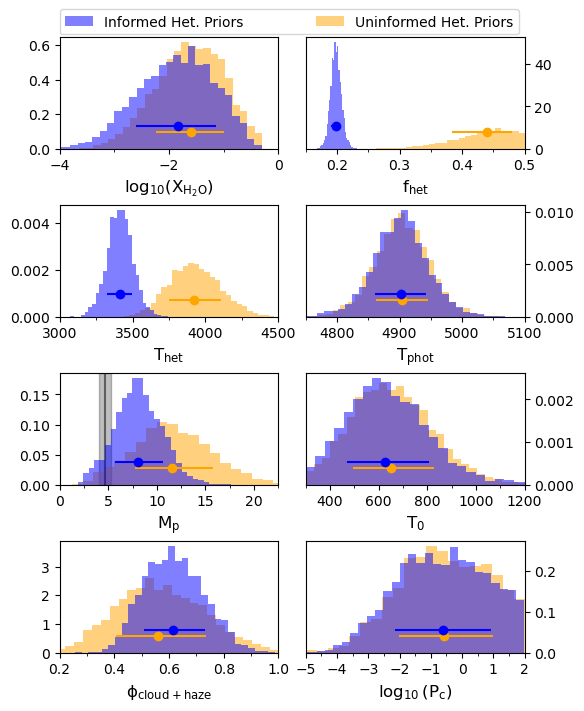

In [3]:
fig = plt.figure(figsize=(6, 8))
gs = gridspec.GridSpec(4, 2, figure=fig, wspace=0.125, hspace=0.5)
axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[0, 1])
axC = fig.add_subplot(gs[1, 0])
axD = fig.add_subplot(gs[1, 1])
axE = fig.add_subplot(gs[2, 0]) 
axF = fig.add_subplot(gs[2, 1])
axG = fig.add_subplot(gs[3, 0])
axH = fig.add_subplot(gs[3, 1])
#axI = fig.add_subplot(gs[4, 0])
#axJ = fig.add_subplot(gs[4, 1])

# top left, H2O
axA.hist(mp_samples[:,0], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled',label='Informed Het. Priors')
axA.hist(mn_samples[:,0], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled',label='Uninformed Het. Priors')
axA.set_xlim(-4,0)
axA.xaxis.set_major_locator(MultipleLocator(2))
axA.xaxis.set_minor_locator(MultipleLocator(1))
axA.set_xlabel(r'$\mathrm{log_{10}\left( X_{H_2O} \right)}$', fontsize=12)

# # top right, f_het
axB.hist(mp_samples[:,19], bins=30, density=True, color='blue', zorder=2, alpha=0.5, histtype='stepfilled')
axB.hist(mn_samples[:,19], bins=30, density=True, color='orange', zorder=2, alpha=0.5, histtype='stepfilled')
axB.set_xlim(0.15,0.5)
axB.xaxis.set_major_locator(MultipleLocator(.1))
axB.xaxis.set_minor_locator(MultipleLocator(.05))
axB.set_xlabel(r'$\mathrm{f_{het}}$', fontsize=12)
axB.yaxis.tick_right()

# # middle top left, Thet
axC.hist(mp_samples[:,20], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axC.hist(mn_samples[:,20], bins=30, density=True, color='orange', alpha=0.5, zorder=1,  histtype='stepfilled')
axC.set_xlim(3000,4500)
axC.xaxis.set_major_locator(MultipleLocator(500))
axC.xaxis.set_minor_locator(MultipleLocator(250))
axC.set_xlabel(r'$\mathrm{T_{het}}$', fontsize=12)

# # middle top right, Tphot
axD.hist(mp_samples[:,21], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axD.hist(mn_samples[:,21], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled')
axD.set_xlim(4750,5100)
axD.xaxis.set_major_locator(MultipleLocator(100))
axD.xaxis.set_minor_locator(MultipleLocator(50))
axD.set_xlabel(r'$\mathrm{T_{phot}}$', fontsize=12)
axD.yaxis.tick_right()

# # middle middle left, mass
axE.axvspan(4.7-0.6, 4.7+0.6, ec='black', fc='black', alpha=0.25)
axE.axvline(4.7, c='black', alpha=0.5)
axE.hist(mp_samples[:,18], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axE.hist(mn_samples[:,18], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled')
axE.set_xlim(0,22.5)
axE.xaxis.set_major_locator(MultipleLocator(5))
axE.xaxis.set_minor_locator(MultipleLocator(2.5))
axE.set_xlabel(r'$\mathrm{M_{p}}$', fontsize=12)

# # middle middle right, T0
axF.hist(mp_samples[:,6], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axF.hist(mn_samples[:,6], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled')
axF.set_xlim(300,1200)
axF.xaxis.set_major_locator(MultipleLocator(200))
axF.xaxis.set_minor_locator(MultipleLocator(100))
axF.set_xlabel(r'$\mathrm{T_{0}}$', fontsize=12)
axF.yaxis.tick_right()

# # middle bottom left, phi_cl
axG.hist(mp_samples[:,16], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axG.hist(mn_samples[:,16], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled')
axG.set_xlim(0.2, 1)
axG.xaxis.set_major_locator(MultipleLocator(.2))
axG.xaxis.set_minor_locator(MultipleLocator(.1))
axG.set_xlabel(r'$\mathrm{\phi_{cloud+haze}}$', fontsize=12)

# # middle bottom right, P_cloud
axH.hist(mp_samples[:,15], bins=30, density=True, color='blue', alpha=0.5, zorder=2, histtype='stepfilled')
axH.hist(mn_samples[:,15], bins=30, density=True, color='orange', alpha=0.5, zorder=1, histtype='stepfilled')
axH.set_xlim(-5,2.)
axH.xaxis.set_major_locator(MultipleLocator(1))
axH.xaxis.set_minor_locator(MultipleLocator(.5))
axH.set_xlabel(r'$\mathrm{\log_{10}\left(P_{c}\right)}$', fontsize=12)
axH.yaxis.tick_right()

ypos = 0.2
axes = [axA, axB, axC, axD, axE, axF, axG, axH]
idxs = [0,19,20,21,18,6,16,15]
# error bars with priors
for ax, val, err_lo, err_hi in zip(axes, mp_vals[idxs], mp_loerrs[idxs], mp_uperrs[idxs]):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.errorbar(val, ypos, xerr=[[err_lo], [err_hi]], fmt='o', transform=trans, c='blue', zorder=6, clip_on=True)
# error bars without priors
for ax, val, err_lo, err_hi in zip(axes, mn_vals[idxs], mn_loerrs[idxs], mn_uperrs[idxs]):
    trans = blended_transform_factory(ax.transData, ax.transAxes)
    ax.errorbar(val, ypos-0.05, xerr=[[err_lo], [err_hi]], fmt='o', transform=trans, c='orange', zorder=5, clip_on=True)

axA.legend(bbox_to_anchor=(0., 1.02, 2.1, .102), loc=3,
               ncol=2, mode="expand", borderaxespad=0)
#plt.tight_layout()
plt.savefig('./figures/Figure6.png', dpi=600, bbox_inches='tight')
plt.savefig('./figures/Figure6.pdf', format='PDF', dpi=600, bbox_inches='tight')
plt.show()